In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [150]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
busi_path = "/content/drive/MyDrive/BUSI"

print(os.listdir(busi_path))

['images', 'labels', 'processed_images', 'best_attention_unet.keras', 'final_attention_unet.keras', 'preprocessing_pipeline.png']


In [99]:
image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"
processed_dir = "/content/drive/MyDrive/BUSI/processed_images"

In [100]:
images = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

labels = sorted([
    f for f in os.listdir(label_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Matching filenames:", len(set(images) & set(labels)))

Total images: 629
Total labels: 629
Matching filenames: 629


Class Distribution:
Benign       420
Malignant    209
Name: count, dtype: int64


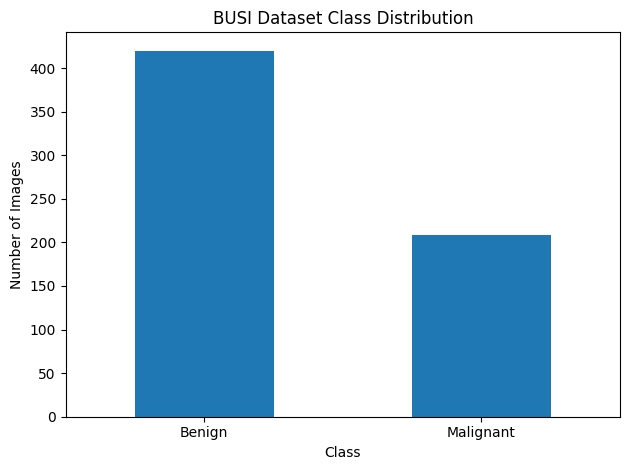

In [101]:
def get_class(filename):
    filename = filename.lower()

    if filename.startswith("benign"):
        return "Benign"
    elif filename.startswith("malignant"):
        return "Malignant"
    elif filename.startswith("normal"):
        return "Normal"
    return "Unknown"


image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

class_counts = pd.Series(
    [get_class(f) for f in image_files]
).value_counts()

print("Class Distribution:")
print(class_counts)

class_counts.plot(
    kind="bar",
    title="BUSI Dataset Class Distribution",
    xlabel="Class",
    ylabel="Number of Images",
    rot=0
)

plt.tight_layout()
plt.show()

In [102]:
pairs = []

for filename in sorted(os.listdir(image_dir)):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        image_file = os.path.join(image_dir, filename)
        label_file = os.path.join(label_dir, filename)

        if os.path.isfile(label_file):
            pairs.append((image_file, label_file))

print("Total image-mask pairs:", len(pairs))

Total image-mask pairs: 629


Image: benign_1.png
Mask: benign_1.png
Image shape: (471, 562, 3)
Mask shape: (471, 562)
Mask values: [0 1]


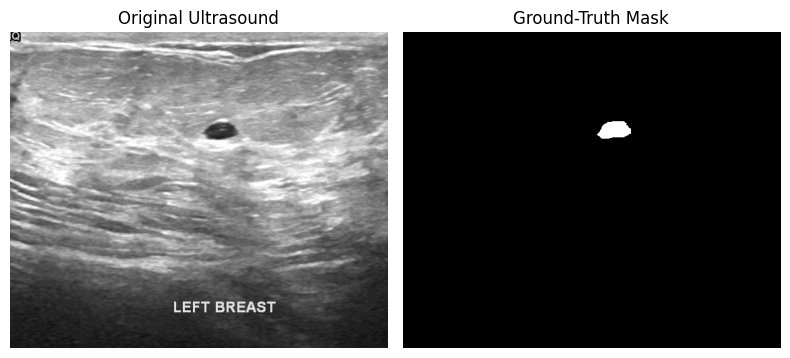

In [103]:
import cv2

image_file, label_file = pairs[0]

image = cv2.imread(image_file)
mask = cv2.imread(label_file, cv2.IMREAD_GRAYSCALE)

print("Image:", os.path.basename(image_file))
print("Mask:", os.path.basename(label_file))
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Ultrasound")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground-Truth Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

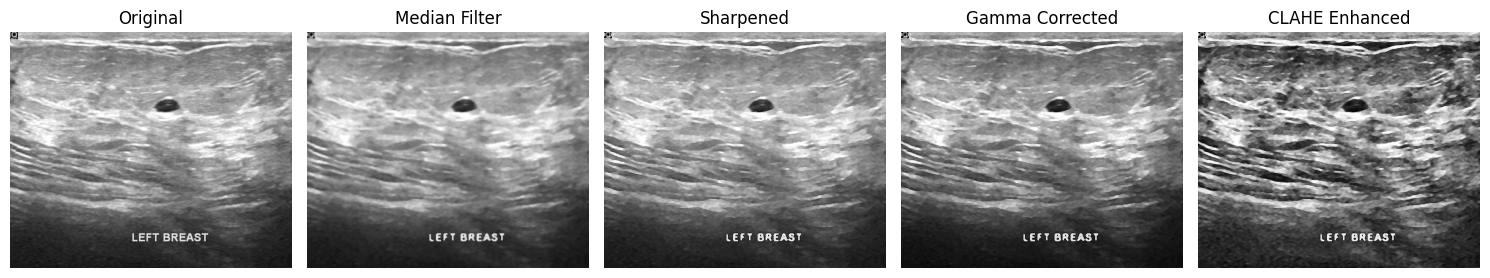

In [104]:
import cv2

image_file, label_file = pairs[0]
img = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

# 1. Median filtering
median = cv2.medianBlur(img, 5)

# 2. Sharpening
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpened = cv2.filter2D(median, -1, kernel)

# 3. Gamma correction
gamma = 1.2
gamma_corrected = (
    np.power(sharpened.astype(np.float32) / 255.0, gamma) * 255
).clip(0, 255).astype(np.uint8)

# 4. CLAHE enhancement
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
final_image = clahe.apply(gamma_corrected)

# Display preprocessing stages
stages = [
    ("Original", img),
    ("Median Filter", median),
    ("Sharpened", sharpened),
    ("Gamma Corrected", gamma_corrected),
    ("CLAHE Enhanced", final_image)
]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, (title, stage) in zip(axes, stages):
    ax.imshow(stage, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [105]:
# Preprocess and save all ultrasound images
os.makedirs(processed_dir, exist_ok=True)

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    # 1. Median filtering
    median = cv2.medianBlur(img, 5)

    # 2. Sharpening
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    sharpened = cv2.filter2D(median, -1, kernel)

    # 3. Gamma correction
    gamma = 1.2
    gamma_corrected = (
        np.power(sharpened.astype(np.float32) / 255.0, gamma) * 255
    ).clip(0, 255).astype(np.uint8)

    # 4. CLAHE enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(gamma_corrected)


for image_file, _ in pairs:
    processed = preprocess_image(image_file)
    filename = os.path.basename(image_file)
    save_path = os.path.join(processed_dir, filename)
    cv2.imwrite(save_path, processed)

print(f"Preprocessing completed: {len(pairs)} images.")

Preprocessing completed: 629 images.


In [106]:
def get_class(filename):
    filename = filename.lower()

    if filename.startswith("benign"):
        return "benign"
    elif filename.startswith("malignant"):
        return "malignant"
    return "normal"


data = []

for image_file, label_file in pairs:
    filename = os.path.basename(image_file)
    processed_file = os.path.join(processed_dir, filename)

    if os.path.exists(processed_file):
        data.append({
            "image": processed_file,
            "label": label_file,
            "class": get_class(filename)
        })

print("Total usable samples:", len(data))

Total usable samples: 629


In [107]:
IMG_SIZE = 256

def prepare_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    return image.astype(np.float32) / 255.0


def prepare_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )
    return (mask > 0).astype(np.float32)

In [108]:
 import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Concatenate, Activation, Add, Multiply
)
from tensorflow.keras.models import Model


# Attention Gate
def attention_gate(x, skip, filters):
    g = Conv2D(filters, 1, padding="same")(x)
    s = Conv2D(filters, 1, padding="same")(skip)

    g = tf.keras.layers.BatchNormalization()(g)
    s = tf.keras.layers.BatchNormalization()(s)

    attention = Add()([g, s])
    attention = Activation("relu")(attention)

    attention = Conv2D(1, 1, padding="same")(attention)
    attention = Activation("sigmoid")(attention)

    return Multiply()([skip, attention])


# Convolution block
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


# Attention U-Net
def attention_unet(input_shape=(256, 256, 1)):

    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D(2)(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D(2)(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D(2)(c3)

    c4 = conv_block(p3, 256)
    p4 = MaxPooling2D(2)(c4)

    # Bottleneck
    bottleneck = conv_block(p4, 512)

    # Decoder
    u4 = UpSampling2D(2)(bottleneck)
    a4 = attention_gate(u4, c4, 256)
    u4 = Concatenate()([u4, a4])
    c5 = conv_block(u4, 256)

    u3 = UpSampling2D(2)(c5)
    a3 = attention_gate(u3, c3, 128)
    u3 = Concatenate()([u3, a3])
    c6 = conv_block(u3, 128)

    u2 = UpSampling2D(2)(c6)
    a2 = attention_gate(u2, c2, 64)
    u2 = Concatenate()([u2, a2])
    c7 = conv_block(u2, 64)

    u1 = UpSampling2D(2)(c7)
    a1 = attention_gate(u1, c1, 32)
    u1 = Concatenate()([u1, a1])
    c8 = conv_block(u1, 32)

    outputs = Conv2D(1, 1, activation="sigmoid")(c8)

    return Model(inputs, outputs)


model = attention_unet()

print("Attention U-Net model created successfully!")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Total parameters:", f"{model.count_params():,}")

Attention U-Net model created successfully!
Input shape: (None, 256, 256, 1)
Output shape: (None, 256, 256, 1)
Total parameters: 8,112,485


In [109]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


def combined_loss(y_true, y_pred):
    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true, y_pred)
    )
    return bce + 1 - dice_coefficient(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [110]:
import tensorflow as tf

print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

GPU available: True


In [111]:
import os
from sklearn.model_selection import train_test_split

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"
processed_dir = "/content/drive/MyDrive/BUSI/processed_images"

# Match images with their masks
common = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_dir)
} & {
    os.path.splitext(f)[0]
    for f in os.listdir(label_dir)
}

pairs = [
    (
        os.path.join(processed_dir, name + ".png"),
        os.path.join(label_dir, name + ".png")
    )
    for name in sorted(common)
    if os.path.exists(os.path.join(processed_dir, name + ".png"))
    and os.path.exists(os.path.join(label_dir, name + ".png"))
]

def get_class(filename):
    filename = filename.lower()
    return "benign" if filename.startswith("benign") else "malignant"

data = [
    {
        "image": image,
        "label": label,
        "class": get_class(os.path.basename(image))
    }
    for image, label in pairs
]

train_data, temp_data = train_test_split(
    data, test_size=0.20, random_state=42,
    stratify=[x["class"] for x in data]
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.50, random_state=42,
    stratify=[x["class"] for x in temp_data]
)

print(f"Total samples: {len(data)}")
print(f"Training: {len(train_data)} | Validation: {len(val_data)} | Testing: {len(test_data)}")

Total samples: 629
Training: 503 | Validation: 63 | Testing: 63


In [136]:
def create_dataset(data):
    images, masks = [], []

    for sample in data:
        images.append(
            prepare_image(sample["image"])[..., np.newaxis]
        )
        masks.append(
            prepare_mask(sample["label"])[..., np.newaxis]
        )

    return (
        np.array(images, dtype=np.float32),
        np.array(masks, dtype=np.float32)
    )

X_train, Y_train = create_dataset(train_data)
X_val, Y_val = create_dataset(val_data)
X_test, Y_test = create_dataset(test_data)

print("Training:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Testing:", X_test.shape, Y_test.shape)

Training: (503, 256, 256, 1) (503, 256, 256, 1)
Validation: (63, 256, 256, 1) (63, 256, 256, 1)
Testing: (63, 256, 256, 1) (63, 256, 256, 1)


In [139]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="/content/drive/MyDrive/BUSI/best_attention_unet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 531ms/step - accuracy: 0.9207 - dice_coefficient: 0.4727 - loss: 0.7621 - val_accuracy: 0.9191 - val_dice_coefficient: 0.3246 - val_loss: 0.8823
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.9277 - dice_coefficient: 0.5130 - loss: 0.7107 - val_accuracy: 0.9198 - val_dice_coefficient: 0.3262 - val_loss: 0.8785
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.9302 - dice_coefficient: 0.5324 - loss: 0.6804 - val_accuracy: 0.9082 - val_dice_coefficient: 0.1227 - val_loss: 1.2380
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.9301 - dice_coefficient: 0.5299 - loss: 0.6811 - val_accuracy: 0.9309 - val_dice_coefficient: 0.4639 - val_loss: 0.7335
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step - accuracy: 0.9335 - dice_coefficient: 0.5543 - loss: 0.6498 - val_accuracy: 0.9340 - val_dice_coefficient: 0.4938 - val_loss: 0.7042
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 

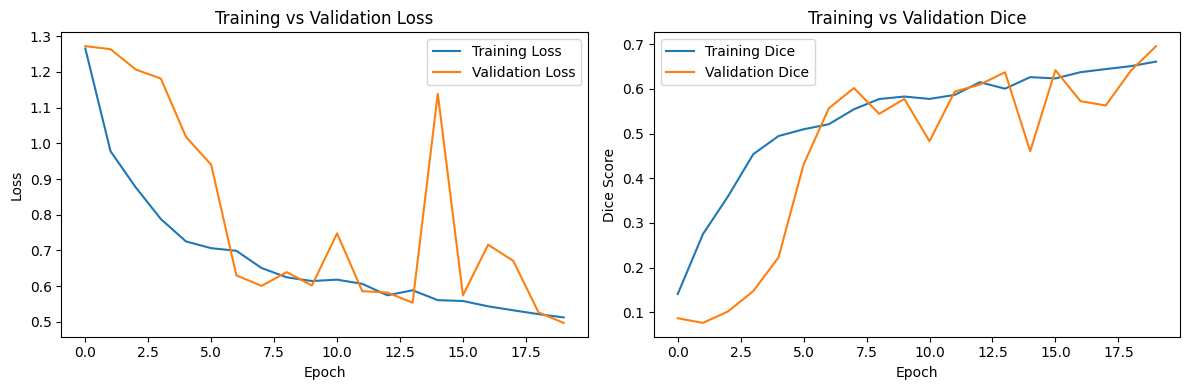

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training and validation loss
axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Training and validation Dice score
axes[1].plot(history.history["dice_coefficient"], label="Training Dice")
axes[1].plot(history.history["val_dice_coefficient"], label="Validation Dice")
axes[1].set_title("Training vs Validation Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].legend()

plt.tight_layout()
plt.show()

In [115]:
import os
from sklearn.model_selection import train_test_split

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"
processed_dir = "/content/drive/MyDrive/BUSI/processed_images"

# Match images with their masks
common = {
    os.path.splitext(f)[0]
    for f in os.listdir(image_dir)
} & {
    os.path.splitext(f)[0]
    for f in os.listdir(label_dir)
}

pairs = [
    (
        os.path.join(processed_dir, name + ".png"),
        os.path.join(label_dir, name + ".png")
    )
    for name in sorted(common)
    if os.path.exists(os.path.join(processed_dir, name + ".png"))
    and os.path.exists(os.path.join(label_dir, name + ".png"))
]

def get_class(filename):
    filename = filename.lower()
    return "benign" if filename.startswith("benign") else "malignant"

data = [
    {
        "image": image,
        "label": label,
        "class": get_class(os.path.basename(image))
    }
    for image, label in pairs
]

train_data, temp_data = train_test_split(
    data, test_size=0.20, random_state=42,
    stratify=[x["class"] for x in data]
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.50, random_state=42,
    stratify=[x["class"] for x in temp_data]
)

print(f"Total samples: {len(data)}")
print(f"Training: {len(train_data)} | Validation: {len(val_data)} | Testing: {len(test_data)}")

Total samples: 629
Training: 503 | Validation: 63 | Testing: 63


In [116]:
X_test, Y_test = create_dataset(test_data)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_test: (63, 256, 256, 1)
Y_test: (63, 256, 256, 1)


In [117]:
Y_pred = model.predict(X_test)

Y_pred_binary = (Y_pred > 0.5).astype(np.float32)

print("Prediction shape:", Y_pred_binary.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
Prediction shape: (63, 256, 256, 1)


In [118]:
print("Prediction shape:", Y_pred.shape)
print("Prediction min:", Y_pred.min())
print("Prediction max:", Y_pred.max())
print("Prediction mean:", Y_pred.mean())
print("Predicted positive pixels:", np.sum(Y_pred_binary))
print("Ground-truth positive pixels:", np.sum(Y_test))

Prediction shape: (63, 256, 256, 1)
Prediction min: 3.2283617e-10
Prediction max: 0.94092953
Prediction mean: 0.007263523
Predicted positive pixels: 5439.0
Ground-truth positive pixels: 446058.0


In [119]:
print("Model input:", model.input_shape)
print("Model output:", model.output_shape)
print("Model parameters:", f"{model.count_params():,}")

Model input: (None, 256, 256, 1)
Model output: (None, 256, 256, 1)
Model parameters: 8,112,485


In [120]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/BUSI/best_attention_unet.keras",
    compile=False
)

In [121]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

y_true = Y_test.flatten()
y_pred = Y_pred_binary.flatten()

intersection = np.sum(y_true * y_pred)
smooth = 1e-7

dice = (2 * intersection + smooth) / (
    np.sum(y_true) + np.sum(y_pred) + smooth
)

union = np.sum(y_true) + np.sum(y_pred) - intersection
iou = (intersection + smooth) / (union + smooth)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

print("Model Evaluation Results")
print(f"Dice Score (F1): {dice:.4f}")
print(f"IoU:             {iou:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"Accuracy:        {accuracy:.4f}")

Model Evaluation Results
Dice Score (F1): 0.0240
IoU:             0.0121
Precision:       0.9963
Recall:          0.0121
Accuracy:        0.8933


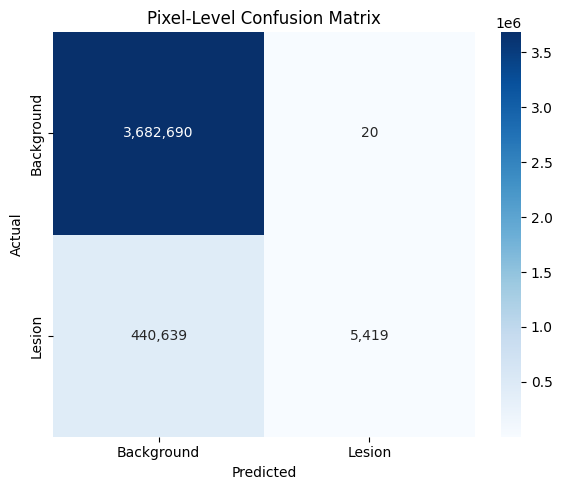

In [122]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["Background", "Lesion"],
    yticklabels=["Background", "Lesion"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pixel-Level Confusion Matrix")
plt.tight_layout()
plt.show()

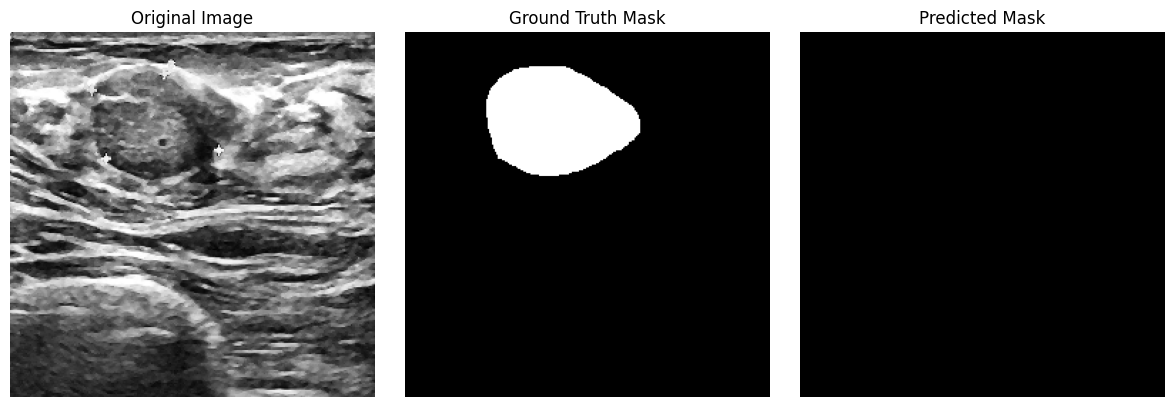

In [123]:
index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y_test[index].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Y_pred_binary[index].squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [124]:
import os

for name in ["best_attention_unet.keras", "final_attention_unet.keras"]:
    path = os.path.join("/content/drive/MyDrive/BUSI", name)
    print(name, round(os.path.getsize(path) / (1024 * 1024), 2), "MB")

best_attention_unet.keras 93.11 MB
final_attention_unet.keras 31.17 MB


In [125]:
!pip install -q gradio

In [126]:
def predict_lesion(image):
    image = np.array(image)

    # Convert to grayscale
    if image.ndim == 3:
        conversion = cv2.COLOR_RGBA2GRAY if image.shape[-1] == 4 else cv2.COLOR_RGB2GRAY
        image = cv2.cvtColor(image, conversion)

    # Preprocess
    image = cv2.medianBlur(image, 5)

    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    image = cv2.filter2D(image, -1, kernel)
    image = (np.power(image / 255.0, 1.2) * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)

    # Resize and normalize
    image = cv2.resize(image, (256, 256)).astype(np.float32) / 255.0
    image = image[np.newaxis, ..., np.newaxis]

    # Predict lesion mask
    prediction = model.predict(image, verbose=0)
    mask = (prediction[0, :, :, 0] > 0.5).astype(np.uint8) * 255

    return (image[0, :, :, 0] * 255).astype(np.uint8), mask

In [127]:
import gradio as gr

demo = gr.Interface(
    fn=predict_lesion,
    inputs=gr.Image(type="numpy", label="Upload Ultrasound"),
    outputs=[
        gr.Image(label="Processed Ultrasound"),
        gr.Image(label="Predicted Lesion Mask")
    ],
    title="Breast Ultrasound Lesion Segmentation",
    description="Segment lesion regions using a trained Attention U-Net model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47578f7a07b93704da.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [128]:
import time

start = time.time()

test_batch = X_test[:1]

print("Starting prediction...")

test_prediction = model.predict(
    test_batch,
    verbose=1
)

print("Prediction finished!")
print("Shape:", test_prediction.shape)
print("Time:", time.time() - start, "seconds")

Starting prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction finished!
Shape: (1, 256, 256, 1)
Time: 0.1204233169555664 seconds


In [129]:
model.save(
    "/content/drive/MyDrive/BUSI/final_attention_unet.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


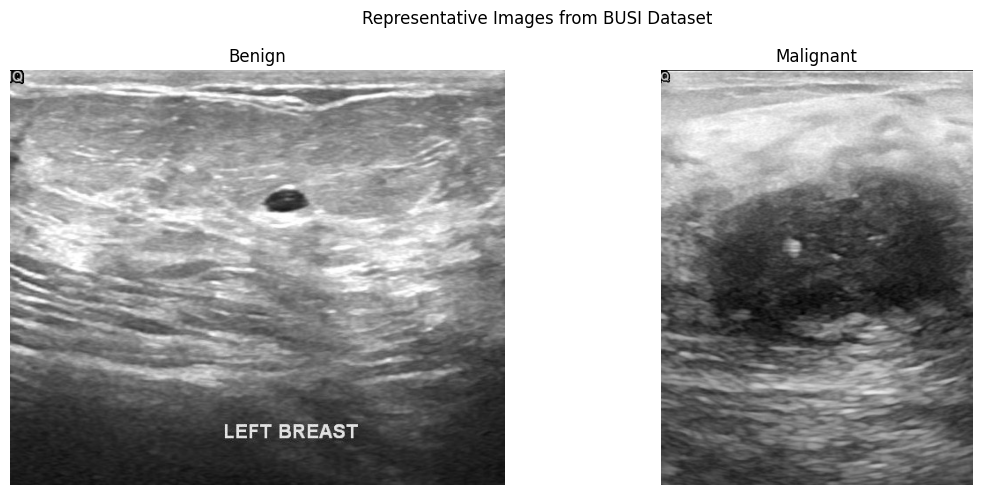

In [130]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

benign_files = [f for f in image_files if "benign" in f.lower()]
malignant_files = [f for f in image_files if "malignant" in f.lower()]

# Select one image from each class
selected = [
    ("Benign", benign_files[0]),
    ("Malignant", malignant_files[0])
]

plt.figure(figsize=(12, 5))

for i, (class_name, filename) in enumerate(selected):
    image_path = os.path.join(image_dir, filename)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Representative Images from BUSI Dataset")
plt.tight_layout()
plt.show()

In [131]:
import os
import cv2
import numpy as np

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

lesion_percentages = []

for filename in image_files:
    label_path = os.path.join(label_dir, filename)

    if os.path.exists(label_path):
        mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

        if mask is not None:
            lesion_pixels = np.sum(mask > 0)
            total_pixels = mask.shape[0] * mask.shape[1]

            percentage = (lesion_pixels / total_pixels) * 100
            lesion_percentages.append(percentage)

print("Number of masks analyzed:", len(lesion_percentages))

print("Average lesion area:",
      round(np.mean(lesion_percentages), 2), "%")

print("Minimum lesion area:",
      round(np.min(lesion_percentages), 2), "%")

print("Maximum lesion area:",
      round(np.max(lesion_percentages), 2), "%")

Number of masks analyzed: 629
Average lesion area: 9.39 %
Minimum lesion area: 0.28 %
Maximum lesion area: 56.29 %


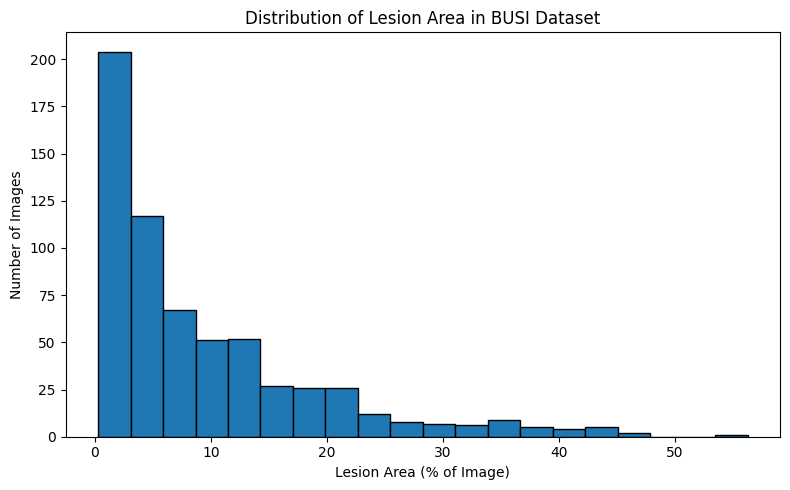

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    lesion_percentages,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Lesion Area in BUSI Dataset")
plt.xlabel("Lesion Area (% of Image)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

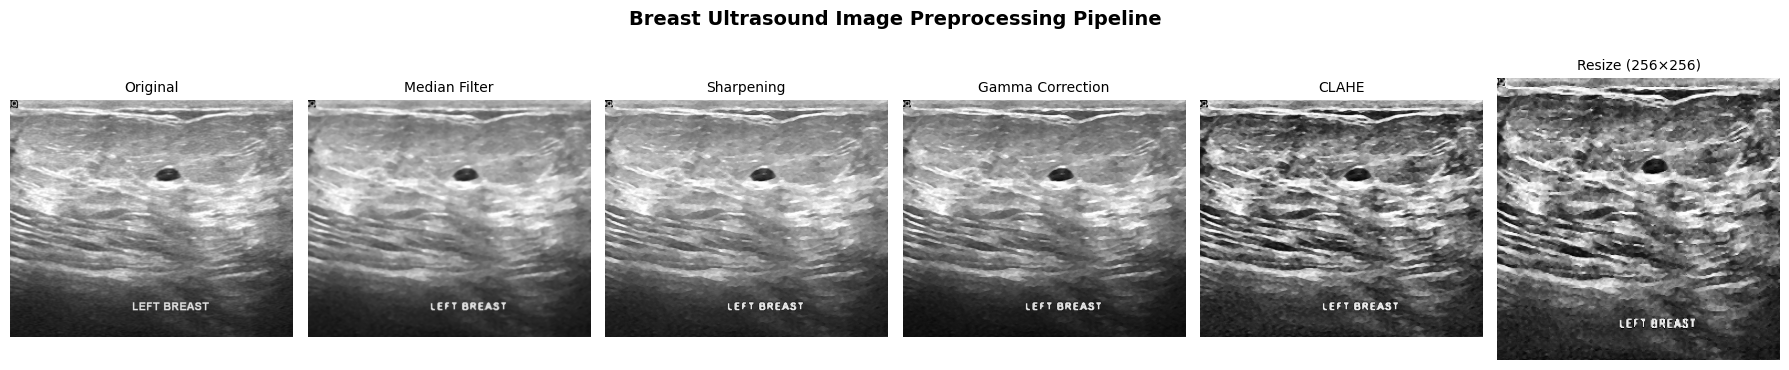

Figure saved at:
/content/drive/MyDrive/BUSI/preprocessing_pipeline.png


In [133]:
# Select one ultrasound image
image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

# Use first benign image
filename = [f for f in image_files if "benign" in f.lower()][0]
image_path = os.path.join(image_dir, filename)

# Read image in grayscale
original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Median Filtering
median = cv2.medianBlur(original, 5)

# 2. Sharpening
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(median, -1, kernel)

# 3. Gamma Correction
gamma = 1.2
gamma_corrected = np.power(
    sharpened / 255.0,
    gamma
) * 255

gamma_corrected = gamma_corrected.astype(np.uint8)

# 4. CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_image = clahe.apply(gamma_corrected)

# 5. Resize
resized = cv2.resize(clahe_image, (256, 256))

# Display all stages
plt.figure(figsize=(18, 4))

images = [
    original,
    median,
    sharpened,
    gamma_corrected,
    clahe_image,
    resized
]

titles = [
    "Original",
    "Median Filter",
    "Sharpening",
    "Gamma Correction",
    "CLAHE",
    "Resize (256×256)"
]

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=10)
    plt.axis("off")

plt.suptitle(
    "Breast Ultrasound Image Preprocessing Pipeline",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Save figure to Google Drive
save_path = "/content/drive/MyDrive/BUSI/preprocessing_pipeline.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved at:")
print(save_path)

In [144]:
%%writefile app.py

import cv2
import numpy as np
import tensorflow as tf
import gradio as gr

model = tf.keras.models.load_model("best_attention_unet.keras", compile=False)

def predict_lesion(image):
    image = np.array(image)
    if image.ndim == 3:
        image = cv2.cvtColor(
            image, cv2.COLOR_RGBA2GRAY if image.shape[-1] == 4 else cv2.COLOR_RGB2GRAY
        )

    image = cv2.medianBlur(image, 5)
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    image = cv2.filter2D(image, -1, kernel)
    image = (np.power(image / 255.0, 1.2) * 255).astype(np.uint8)
    image = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(image)
    resized = cv2.resize(image, (256, 256))
    input_image = (resized.astype(np.float32) / 255.0)[None, ..., None]

    prediction = model.predict(input_image, verbose=0)
    mask = (prediction[0, :, :, 0] > 0.5).astype(np.uint8) * 255
    return resized, mask

demo = gr.Interface(
    fn=predict_lesion,
    inputs=gr.Image(type="numpy", label="Upload Ultrasound Image"),
    outputs=[
        gr.Image(label="Processed Ultrasound"),
        gr.Image(label="Predicted Lesion Mask")
    ],
    title="Breast Ultrasound Lesion Segmentation",
    description="Academic prototype for lesion segmentation only; not for medical diagnosis."
)

if __name__ == "__main__":
    demo.launch()

Overwriting app.py


In [145]:
%%writefile README.md

# Breast Ultrasound Lesion Segmentation Using Attention U-Net

## Overview
An Attention U-Net deep learning project for segmenting lesion regions in breast ultrasound images. It uses image preprocessing and generates binary segmentation masks.

**Disclaimer:** Academic prototype only; not intended for medical diagnosis.

## Dataset
Uses the Breast Ultrasound Images (BUSI) dataset.

- Total images: 629
- Benign: 420
- Malignant: 209
- Segmentation masks: 629

The dataset is not included in this repository.

## Methodology
1. Dataset preparation and image-mask pairing
2. Preprocessing: median filtering, sharpening, gamma correction and CLAHE
3. Resizing to 256 × 256 and normalization to 0–1
4. Attention U-Net training using combined Binary Cross-Entropy and Dice loss
5. Lesion segmentation and model evaluation
6. Gradio web interface

## Dataset Split
- Training: 503 images
- Validation: 63 images
- Testing: 63 images

## Evaluation Results

| Metric | Score |
|---|---:|
| Dice / F1-score | 0.7344 |
| IoU | 0.5803 |
| Precision | 0.7994 |
| Recall | 0.6793 |
| Accuracy | 0.9469 |

## Web Interface
The Gradio app accepts an ultrasound image and returns the processed image and predicted lesion mask.

## Technologies
Python, TensorFlow/Keras, OpenCV, NumPy, Pandas, Scikit-learn, Matplotlib, Gradio and Google Colab.

## Repository Contents
- `breast_ultrasound_segmentation.ipynb` – Project notebook
- `app.py` – Gradio application
- `requirements.txt` – Dependencies
- `LICENSE` – MIT License

## License
MIT License.

**Note:** Segmentation results are not a medical diagnosis or a substitute for professional clinical assessment.

Overwriting README.md


In [149]:
import shutil
import os

source_files = {
    "/content/best_attention_unet.keras": "best_attention_unet.keras",
    "/content/README.md": "README.md",
    "/content/requirements.txt": "requirements.txt",
    "/content/app.py": "app.py"
}

repo_path = "/content/breast-ultrasound-attention-unet"

for source, filename in source_files.items():
    shutil.copy(source, os.path.join(repo_path, filename))

print("Project files copied successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_attention_unet.keras'

In [ ]:
!git lfs track "*.keras"

In [ ]:
!git config --global user.name "Siddhi-i"
!git config --global user.email "siddhilagad3301@gmail.com"

In [ ]:
!git commit -m "Add trained Attention U-Net model and project files"

In [ ]:
%cd /content/breast-ultrasound-attention-unet
!git status

In [143]:
!ls -la /content/

total 32
drwxr-xr-x 1 root root 4096 Oct  9 00:39 .
drwxr-xr-x 1 root root 4096 Oct  8 23:27 ..
-rw-r--r-- 1 root root 1333 Oct  9 00:38 app.py
drwxr-xr-x 4 root root 4096 Sep 30 13:28 .config
drwx------ 5 root root 4096 Oct  8 23:42 drive
drwxr-xr-x 3 root root 4096 Oct  9 01:11 .gradio
-rw-r--r-- 1 root root 1661 Oct  9 00:39 README.md
drwxr-xr-x 1 root root 4096 Sep 30 13:28 sample_data


In [151]:
!ls -la /content/drive/MyDrive/

total 137277
drwx------ 5 root root     4096 Oct  8 23:42  .
drwx------ 5 root root     4096 Oct  8 23:42  ..
-rw------- 1 root root   119947 Jul 19  2021  1000026209.jpeg
-rw------- 1 root root  4380804 Feb 14  2024  1000069692.jpeg
-rw------- 1 root root      188 Sep 20  2024 '11DSL PRINTS.gdoc'
-rw------- 1 root root      188 Mar  7  2026 '52_BI ASSIGNMENT.gdoc'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad (1).pdf'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad (2).pdf'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad (3).pdf'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad (4).pdf'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad (5).pdf'
-rw------- 1 root root      188 Mar 19  2026 '52_Siddhi Lagad_ Flutter10.gdoc'
-rw------- 1 root root    58397 Jan  8  2026 '52_ Siddhi Lagad.pdf'
-rw------- 1 root root   167850 Apr 23  2024 '52-SIDDHI LAGAD-SMART ENGLISH BASICS FOR PROFESSIONALS  (1).pdf'
-rw------- 1 r

In [152]:
!find /content/drive/MyDrive -iname "*breast*" -print

/content/drive/MyDrive/Colab Notebooks/breast_ultrasound_segmentation.ipynb


In [153]:
!find /content/drive/MyDrive -type f \( -iname "*.keras" -o -iname "*.h5" -o -iname "*.zip" -o -iname "*.npy" -o -iname "*.nii" -o -iname "*.nii.gz" \) -print

/content/drive/MyDrive/BUSI/best_attention_unet.keras
/content/drive/MyDrive/BUSI/final_attention_unet.keras


In [154]:
!git ls-remote https://github.com/Siddhi-i/breast-ultrasound-attention-unet

474ad07bc6db03e5b0fdcc046efff6b62d2db57f	HEAD
474ad07bc6db03e5b0fdcc046efff6b62d2db57f	refs/heads/main


In [155]:
%cd /content
!git clone https://github.com/Siddhi-i/breast-ultrasound-attention-unet.git

/content
Cloning into 'breast-ultrasound-attention-unet'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 2), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 1.75 MiB | 4.80 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [157]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [158]:
%cd /content/breast-ultrasound-attention-unet
!git status

/content/breast-ultrasound-attention-unet
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [159]:
!ls -lah

total 2.6M
drwxr-xr-x 3 root root 4.0K Oct  9 01:35 .
drwxr-xr-x 1 root root 4.0K Oct  9 01:35 ..
-rw-r--r-- 1 root root 2.3K Oct  9 01:35 app.py
-rw-r--r-- 1 root root  133 Oct  9 01:35 best_attention_unet.keras
-rw-r--r-- 1 root root 2.6M Oct  9 01:35 breast_ultrasound_segmentation.ipynb
drwxr-xr-x 8 root root 4.0K Oct  9 01:37 .git
-rw-r--r-- 1 root root   44 Oct  9 01:35 .gitattributes
-rw-r--r-- 1 root root 1.1K Oct  9 01:35 LICENSE
-rw-r--r-- 1 root root 2.5K Oct  9 01:35 README.md
-rw-r--r-- 1 root root   85 Oct  9 01:35 requirements.txt
